In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

## Creating Burgers Dataset

dx = 0.06274509803921546
dt = 0.002000400080016003
stability limit = 0.0098423683198769


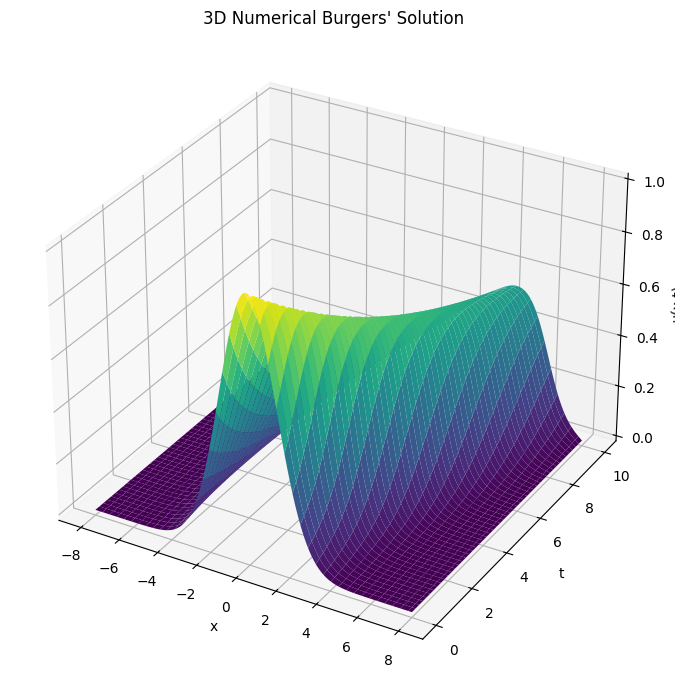

Subsampled shape: (250, 128)
              u           u_x      u_xx         u_u_x             y
0  1.125352e-07  5.788314e-07  0.000001  6.513889e-14 -2.812817e-06
1  1.851728e-07  7.561180e-07  0.000003  1.400125e-13 -3.574544e-07
2  3.023060e-07  1.213200e-06  0.000005  3.667575e-13  7.862865e-07
3  4.896622e-07  1.930857e-06  0.000007  9.454674e-13  1.434267e-06
4  7.869131e-07  3.048169e-06  0.000011  2.398644e-12  2.237172e-06

Saved:
datasets/burgers_dataset.csv

Dataset shape:
(32000, 5)

Expected PDE:
u_t = -u*u_x + 0.2*u_xx


In [ ]:
os.makedirs("datasets", exist_ok=True)
# ------------------------------------------------------------
# 1. Burgers' PDE setup
# u_t = -u*u_x + nu*u_xx
# x in [-8, 8], t in [0, 10]
# ------------------------------------------------------------

nu = 0.2
nx = 256
nt = 5000

x = np.linspace(-8, 8, nx)
t = np.linspace(0, 10, nt)
dx = x[1] - x[0]
dt = t[1] - t[0]
print("dx =", dx)
print("dt =", dt)
print("stability limit =", dx**2 / (2 * nu))
u_data = np.zeros((nt, nx))
# Initial condition
u_data[0, :] = np.exp(-0.25 * x**2)
# ------------------------------------------------------------
# 2. Burgers' PDE numerical approximation
# explicit finite difference
# ------------------------------------------------------------
for n in range(nt - 1):
    u = u_data[n, :].copy()
    u_x = np.zeros_like(u)
    u_xx = np.zeros_like(u)
    # Central difference
    u_x[1:-1] = (u[2:] - u[:-2]) / (2 * dx)
    u_xx[1:-1] = (u[2:] - 2 * u[1:-1] + u[:-2]) / (dx**2)
    # Boundary derivatives
    u_x[0] = 0
    u_x[-1] = 0
    u_xx[0] = 0
    u_xx[-1] = 0
    # Forward Euler update
    u_data[n + 1, :] = (u + dt * (-u * u_x + nu * u_xx))
    # Dirichlet BC
    u_data[n + 1, 0] = 0
    u_data[n + 1, -1] = 0
# ------------------------------------------------------------
# 3. 3D plot of numerical solution
# ------------------------------------------------------------
X_grid, T_grid = np.meshgrid(x, t)
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(X_grid, T_grid, u_data, cmap="viridis", linewidth=0, antialiased=True)
ax.set_title("3D Numerical Burgers' Solution")
ax.set_xlabel("x")
ax.set_ylabel("t")
ax.set_zlabel("u(x,t)")
plt.tight_layout()
plt.show()
# ------------------------------------------------------------
# 4. Subsampling before symbolic regression
# ------------------------------------------------------------
time_stride = 20
space_stride = 2
u_sub = u_data[::time_stride, ::space_stride]
x_sub = x[::space_stride]
t_sub = t[::time_stride]
print("Subsampled shape:", u_sub.shape)
dx_sub = x_sub[1] - x_sub[0]
dt_sub = t_sub[1] - t_sub[0]
# ------------------------------------------------------------
# 5. Computing derivatives on subsampled data
# ------------------------------------------------------------
u_t = np.gradient(u_sub, dt_sub, axis=0)
u_x = np.gradient(u_sub, dx_sub, axis=1)
u_xx = np.gradient(u_x, dx_sub, axis=1)
u_u_x = u_sub * u_x
# ------------------------------------------------------------
# 6. Save symbolic regression dataset
# y = u_t
# ------------------------------------------------------------

df = pd.DataFrame({
    "u": u_sub.flatten(),
    "u_x": u_x.flatten(),
    "u_xx": u_xx.flatten(),
    "u_u_x": u_u_x.flatten(),
    "y": u_t.flatten()
})

df = df.replace([np.inf, -np.inf], np.nan).dropna()
df.to_csv("datasets/burgers_dataset.csv", index=False)
print(df.head())
print("\nSaved:")
print("datasets/burgers_dataset.csv")
print("\nDataset shape:")
print(df.shape)
print("\nExpected PDE:")
print("u_t = -u*u_x + 0.2*u_xx")

In [ ]:
!rm -rf '/content/datasets'

## Creating Kuramoto-Sivanshinsky Dataset

dx = 0.39269908169872414
dt = 0.010002000400080016


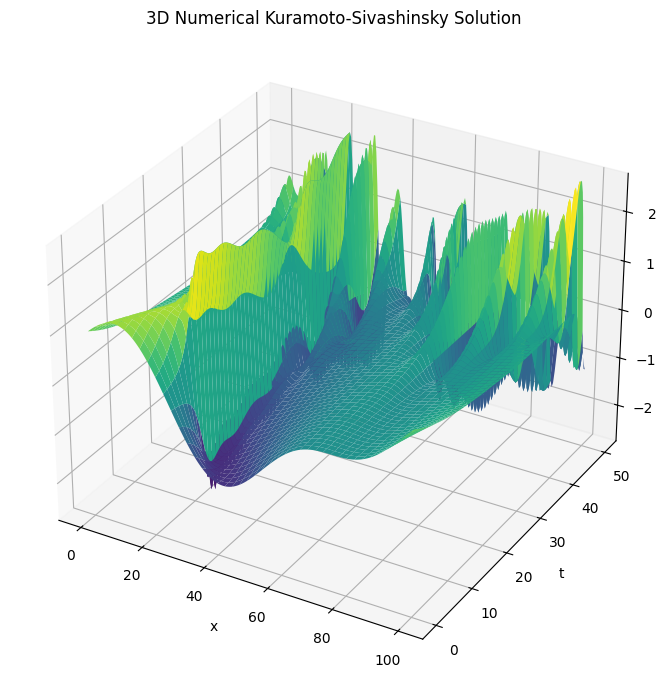

Subsampled shape: (250, 128)
          u       u_x      u_xx    u_xxxx     u_u_x         y
0  1.000000  0.060866 -0.002333 -0.000297  0.060866 -0.058509
1  1.047804  0.059034 -0.003685  0.000109  0.061856 -0.057393
2  1.092730  0.055077 -0.005404  0.000675  0.060184 -0.055189
3  1.134319  0.050546 -0.006121  0.000446  0.057335 -0.051846
4  1.172127  0.045462 -0.006808  0.000061  0.053287 -0.047343

Saved:
datasets/ks_dataset.csv

Dataset shape:
(32000, 6)

Expected PDE:
u_t = -u*u_x - u_xx - u_xxxx


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

os.makedirs("datasets", exist_ok=True)

# ------------------------------------------------------------
# 1. Kuramoto-Sivashinsky PDE setup
# u_t = -u*u_x - u_xx - u_xxxx
# ------------------------------------------------------------
nx = 256
nt = 5000
x_min = 0
x_max = 32 * np.pi
t_min = 0
t_max = 50

x = np.linspace(x_min, x_max, nx, endpoint=False)
t = np.linspace(t_min, t_max, nt)
dx = x[1] - x[0]
dt = t[1] - t[0]
print("dx =", dx)
print("dt =", dt)

# Wavenumbers for spectral derivatives
Lx = x_max - x_min
k = 2 * np.pi * np.fft.fftfreq(nx, d=dx)

# Linear operator for: -u_xx - u_xxxx
# Fourier: u_xx -> -k^2 u_hat
#          u_xxxx -> k^4 u_hat
# so -u_xx - u_xxxx -> k^2 u_hat - k^4 u_hat
linear_operator = k**2 - k**4
u_data = np.zeros((nt, nx))

# Initial condition
u_data[0, :] = np.cos(x / 16) * (1 + np.sin(x / 16))
# ------------------------------------------------------------
# 2. KS PDE numerical approximation
# semi-implicit spectral Euler
# ------------------------------------------------------------
u_hat = np.fft.fft(u_data[0, :])
for n in range(nt - 1):
    u = np.real(np.fft.ifft(u_hat))
    # Nonlinear term: -u*u_x = -0.5 * d(u^2)/dx
    u2_hat = np.fft.fft(u**2)
    nonlinear_hat = -0.5j * k * u2_hat
    # Semi-implicit update
    u_hat = (u_hat + dt * nonlinear_hat) / (1 - dt * linear_operator)
    u_data[n + 1, :] = np.real(np.fft.ifft(u_hat))
# ------------------------------------------------------------
# 3. 3D plot of numerical solution
# ------------------------------------------------------------
X_grid, T_grid = np.meshgrid(x, t)
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(X_grid, T_grid, u_data, cmap="viridis", linewidth=0, antialiased=True)
ax.set_title("3D Numerical Kuramoto-Sivashinsky Solution")
ax.set_xlabel("x")
ax.set_ylabel("t")
ax.set_zlabel("u(x,t)")
plt.tight_layout()
plt.show()
# ------------------------------------------------------------
# 4. Subsample before symbolic regression
# ------------------------------------------------------------
time_stride = 20
space_stride = 2
u_sub = u_data[::time_stride, ::space_stride]
x_sub = x[::space_stride]
t_sub = t[::time_stride]
print("Subsampled shape:", u_sub.shape)
dx_sub = x_sub[1] - x_sub[0]
dt_sub = t_sub[1] - t_sub[0]
# ------------------------------------------------------------
# 5. Compute derivatives on subsampled data
# ------------------------------------------------------------
u_t = np.gradient(u_sub, dt_sub, axis=0)
u_x = np.gradient(u_sub, dx_sub, axis=1)
u_xx = np.gradient(u_x, dx_sub, axis=1)
u_xxx = np.gradient(u_xx, dx_sub, axis=1)
u_xxxx = np.gradient(u_xxx, dx_sub, axis=1)
u_u_x = u_sub * u_x
# ------------------------------------------------------------
# 6. Save symbolic regression dataset
# y = u_t
# ------------------------------------------------------------
df = pd.DataFrame({
    "u": u_sub.flatten(),
    "u_x": u_x.flatten(),
    "u_xx": u_xx.flatten(),
    "u_xxxx": u_xxxx.flatten(),
    "u_u_x": u_u_x.flatten(),
    "y": u_t.flatten()
})

df = df.replace([np.inf, -np.inf], np.nan).dropna()
df.to_csv("datasets/ks_dataset.csv", index=False)

print(df.head())
print("\nSaved:")
print("datasets/ks_dataset.csv")
print("\nDataset shape:")
print(df.shape)
print("\nExpected PDE:")
print("u_t = -u*u_x - u_xx - u_xxxx")

## Generating Datasets

In [ ]:
def generate_burgers_dataset(nu=0.2, nx=256, nt=5000, x_min=-8, x_max=8, t_min=0, t_max=10, time_stride=20, space_stride=2):
    """
    Generating a symbolic-regression dataset for Burgers' PDE:
        u_t = -u*u_x + nu*u_xx
    """
    x = np.linspace(x_min, x_max, nx)
    t = np.linspace(t_min, t_max, nt)
    dx = x[1] - x[0]
    dt = t[1] - t[0]
    print("dx =", dx)
    print("dt =", dt)
    print("stability limit =", dx**2 / (2 * nu))
    u_data = np.zeros((nt, nx))
    # Initial condition
    u_data[0, :] = np.exp(-0.25 * x**2)
    # Solving PDE
    for n in range(nt - 1):
        u = u_data[n, :].copy()
        u_x = np.zeros_like(u)
        u_xx = np.zeros_like(u)
        u_x[1:-1] = (u[2:] - u[:-2]) / (2 * dx)
        u_xx[1:-1] = (u[2:] - 2 * u[1:-1] + u[:-2]) / dx**2
        u_data[n + 1, :] = u + dt * (-u * u_x + nu * u_xx)
        # Boundary condition
        u_data[n + 1, 0] = 0
        u_data[n + 1, -1] = 0
    # Subsampling
    u_sub = u_data[::time_stride, ::space_stride]
    x_sub = x[::space_stride]
    t_sub = t[::time_stride]
    dx_sub = x_sub[1] - x_sub[0]
    dt_sub = t_sub[1] - t_sub[0]
    print("Subsampled shape:", u_sub.shape)
    # Compute derivatives
    u_t = np.gradient(u_sub, dt_sub, axis=0)
    u_x = np.gradient(u_sub, dx_sub, axis=1)
    u_xx = np.gradient(u_x, dx_sub, axis=1)
    u_u_x = u_sub * u_x
    # Build dataframe
    df = pd.DataFrame({
        "u": u_sub.flatten(),
        "u_x": u_x.flatten(),
        "u_xx": u_xx.flatten(),
        "u_u_x": u_u_x.flatten(),
        "y": u_t.flatten()
    })
    df = df.replace([np.inf, -np.inf], np.nan).dropna()
    return df

In [ ]:
def generate_ks_dataset(nx=256, nt=5000, x_min=0, x_max=32 * np.pi, t_min=0, t_max=50, time_stride=20, space_stride=2):
    """
    Generating a symbolic-regression dataset for the Kuramoto-Sivashinsky PDE:
        u_t = -u*u_x - u_xx - u_xxxx
    """
    x = np.linspace(x_min, x_max, nx, endpoint=False)
    t = np.linspace(t_min, t_max, nt)
    dx = x[1] - x[0]
    dt = t[1] - t[0]
    print("dx =", dx)
    print("dt =", dt)
    # Wavenumbers for spectral derivatives
    k = 2 * np.pi * np.fft.fftfreq(nx, d=dx)
    # Linear operator for -u_xx - u_xxxx
    linear_operator = k**2 - k**4
    u_data = np.zeros((nt, nx))
    # Initial condition
    u_data[0, :] = np.cos(x / 16) * (1 + np.sin(x / 16))
    # Initial Fourier coefficients
    u_hat = np.fft.fft(u_data[0, :])
    # Solving KS using semi-implicit spectral Euler
    for n in range(nt - 1):
        u = np.real(np.fft.ifft(u_hat))
        # Nonlinear term: -u*u_x = -0.5 * d(u^2)/dx
        u2_hat = np.fft.fft(u**2)
        nonlinear_hat = -0.5j * k * u2_hat
        # Semi-implicit update
        u_hat = (u_hat + dt * nonlinear_hat) / (1 - dt * linear_operator)
        u_data[n + 1, :] = np.real(np.fft.ifft(u_hat))
    # Subsampling
    u_sub = u_data[::time_stride, ::space_stride]
    x_sub = x[::space_stride]
    t_sub = t[::time_stride]
    dx_sub = x_sub[1] - x_sub[0]
    dt_sub = t_sub[1] - t_sub[0]
    print("Subsampled shape:", u_sub.shape)
    # Computing derivatives
    u_t = np.gradient(u_sub, dt_sub, axis=0)
    u_x = np.gradient(u_sub, dx_sub, axis=1)
    u_xx = np.gradient(u_x, dx_sub, axis=1)
    u_xxx = np.gradient(u_xx, dx_sub, axis=1)
    u_xxxx = np.gradient(u_xxx, dx_sub, axis=1)
    u_u_x = u_sub * u_x
    df = pd.DataFrame({
        "u": u_sub.flatten(),
        "u_x": u_x.flatten(),
        "u_xx": u_xx.flatten(),
        "u_xxxx": u_xxxx.flatten(),
        "u_u_x": u_u_x.flatten(),
        "y": u_t.flatten()
    })
    df = df.replace([np.inf, -np.inf], np.nan).dropna()
    return df

## Equation Discovery Helpers

In [ ]:
!pip install gplearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 78.9 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [ ]:
from gplearn.genetic import SymbolicRegressor
from sklearn.metrics import mean_squared_error

In [ ]:
def load_dataset(csv_path, target_col='y'):
    df = pd.read_csv(csv_path)
    X = df.drop(columns=[target_col]).values
    y = df[target_col].values
    return X, y


def train_symbolic_regressor_burgers(X_train, y_train, X_test, y_test):
    """
    Training a symbolic regressor using genetic programming
    """
    est = SymbolicRegressor(
        population_size=1000,          # Number of candidate equations/programs in each generation
        generations=80,                # Number of evolutionary iterations
        tournament_size=100,           # Number of candidates compared during parent selection
        stopping_criteria=0.001,
        init_depth=(2, 4),             # Initial expression tree depth range
        const_range=(-2, 2),           # Range for random numerical constants
        init_method='full',            # Generate full trees during initialization
        function_set=['add', 'sub', 'mul'],  # Allowed symbolic operations
        parsimony_coefficient=0.001,   # Penalizes overly complex expressions
        p_crossover=0.7,               # Probability of crossover between two parent expressions
        p_subtree_mutation=0.1,        # Probability of replacing a subtree
        p_hoist_mutation=0.05,         # Probability of simplifying by hoisting a subtree
        p_point_mutation=0.1,          # Probability of mutating individual nodes
        max_samples=0.8,               # Fraction of training samples used per generation
        verbose=1,
        n_jobs=-1,
        random_state=42
    )
    est.fit(X_train, y_train)
    y_pred = est.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    print("MSE test:", mse)
    print("formula :", est._program)
    return est

def train_symbolic_regressor_ks(X_train, y_train, X_test, y_test):
    est = SymbolicRegressor(
        population_size=3000,          # Number of candidate symbolic expressions per generation
        generations=150,               # Total number of evolutionary generations
        tournament_size=100,           # Number of individuals competing during selection
        stopping_criteria=0.00001,     # Stop training early if target fitness/error is achieved
        init_depth=(2, 5),             # Initial symbolic expression tree depth range
        const_range=(-2, 2),           # Allowed range for random constants in expressions
        init_method='half and half',   # Use both full and grow initialization strategies
        function_set=['add', 'sub', 'mul'],  # Allowed symbolic operators
        parsimony_coefficient=0.0001,  # Penalizes overly complex symbolic equations
        p_crossover=0.7,               # Probability of crossover between parent expressions
        p_subtree_mutation=0.15,       # Probability of replacing a subtree with a random subtree
        p_hoist_mutation=0.05,         # Probability of simplifying expressions via hoist mutation
        p_point_mutation=0.1,          # Probability of mutating individual nodes/operators
        max_samples=0.8,               # Fraction of training samples used per generation
        verbose=1,
        n_jobs=-1,
        random_state=42
    )
    est.fit(X_train, y_train)
    y_pred = est.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    print("MSE test:", mse)
    print("formula :", est._program)
    return est

## Utility Functions

In [ ]:
import re

In [ ]:
def convert_formula(expr: str, var_map: dict = None):
    """
    Converting a symbolic formula from gplearn prefix style into readable infix style
    Example:
        sub(sub(sub(X2, X2), X3), mul(-0.320, X2))
    becomes:
        (((u_xx - u_xx) - u_u_x) - (-0.320 * u_xx))
    """
    # Default mapping from symbolic regression variables to PDE feature names
    if var_map is None:
      var_map = {
          "X0": "u",
          "X1": "u_x",
          "X2": "u_xx",
          "X3": "u_xxxx",
          "X4": "u_u_x"
      }
    # Supported binary operators and their infix symbols
    binary_ops = {
        "add": "+",
        "sub": "-",
        "mul": "*",
        "div": "/"
    }
    # Supported unary operators
    unary_ops = {
        "sqrt": "np.sqrt",
        "cos": "np.cos"
    }

    def split_args(s):
        args = []
        depth = 0
        start = 0
        for i, ch in enumerate(s):
            if ch == "(":
                depth += 1
            elif ch == ")":
                depth -= 1
            elif ch == "," and depth == 0:
                args.append(s[start:i].strip())
                start = i + 1
        args.append(s[start:].strip())
        return args

    def parse(s):
        s = s.strip()
        for old, new in var_map.items():
            if s == old:
                return new
        for func, op in binary_ops.items():
            prefix = func + "("
            if s.startswith(prefix) and s.endswith(")"):
                inside = s[len(prefix):-1]
                a, b = split_args(inside)
                return f"({parse(a)} {op} {parse(b)})"
        for func, op in unary_ops.items():
            prefix = func + "("
            if s.startswith(prefix) and s.endswith(")"):
                inside = s[len(prefix):-1]
                return f"{op}({parse(inside)})"
        return s
    return parse(expr)

## Equation 1: Burger's Eq

In [ ]:
from sklearn.model_selection import train_test_split
import sympy as sp

dx = 0.06274509803921546
dt = 0.002000400080016003
stability limit = 0.0098423683198769
Subsampled shape: (250, 128)
    |   Population Average    |             Best Individual              |
---- ------------------------- ------------------------------------------ ----------
 Gen   Length          Fitness   Length          Fitness      OOB Fitness  Time Left
   0    18.02         0.588666       15         0.015926         0.016031      2.80m
   1     8.11         0.091419        7        0.0094345       0.00969636      2.59m
   2     5.04         0.189448        7       0.00938017       0.00991366      2.52m
   3     6.75         0.106896        7        0.0093407        0.0100715      3.22m
   4     7.18         0.119198        7          0.00653       0.00672858      3.72m
   5     7.23         0.101236        7       0.00652911       0.00673217      3.30m
   6     7.11         0.122492        7       0.00647508       0.00694825      2.62m
   7     7.06         0.114656        7    

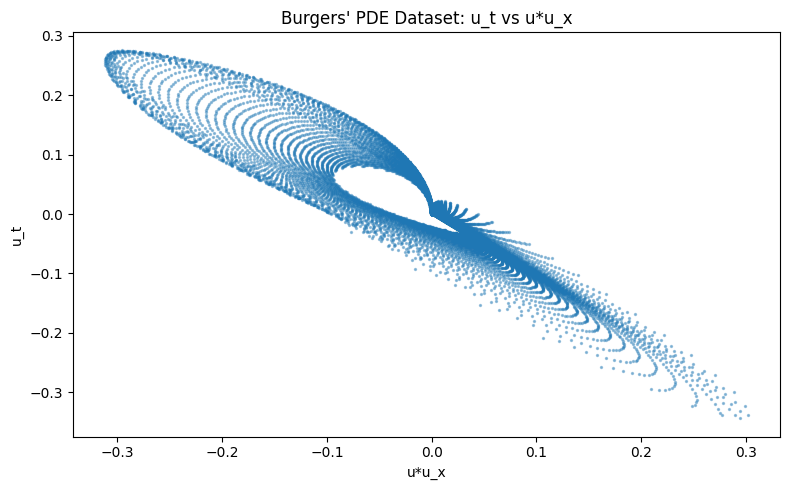

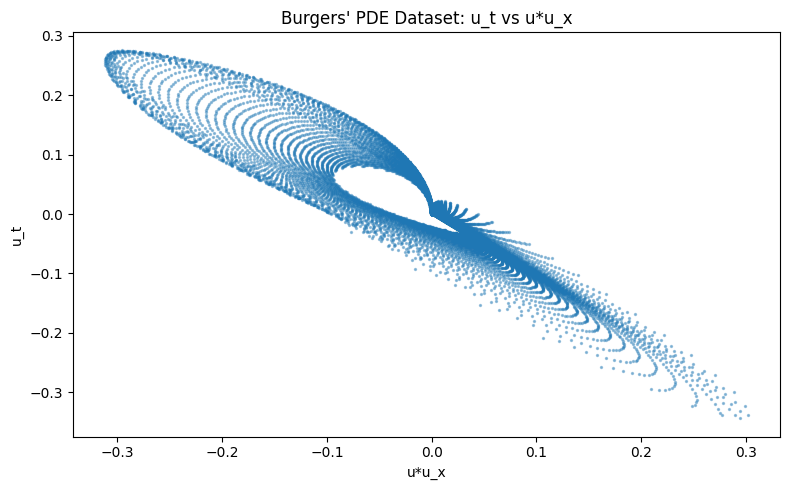

In [ ]:
def create_burgers_plot(csv_file, output_name):
    df = pd.read_csv(csv_file)
    plt.figure(figsize=(8, 5))
    plt.scatter(df["u_u_x"], df["y"], s=2, alpha=0.4)
    plt.xlabel("u*u_x")
    plt.ylabel("u_t")
    plt.title("Burgers' PDE Dataset: u_t vs u*u_x")
    plt.tight_layout()
    plt.savefig(output_name, dpi=300)
    plt.show()

df = generate_burgers_dataset(nu=0.2, nx=256, nt=5000, time_stride=20, space_stride=2)
df.to_csv("datasets/burgers_dataset.csv", index=False)
X, y = load_dataset("datasets/burgers_dataset.csv", target_col="y")
# Training symbolic regressor
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=42)
model = train_symbolic_regressor_burgers(X_train, y_train, X_test, y_test)
# Converting discovered formula
gen_formula = convert_formula(
    str(model._program),
    var_map={
        "X0": "u",
        "X1": "u_x",
        "X2": "u_xx",
        "X3": "u_u_x"
    }
)
# Cleaning formula
u, u_x, u_xx, u_u_x = sp.symbols("u u_x u_xx u_u_x")
clean_formula = sp.sympify(
    gen_formula,
    locals={
        "u": u,
        "u_x": u_x,
        "u_xx": u_xx,
        "u_u_x": u_u_x
    }
)
clean_formula = sp.expand(clean_formula)
clean_formula = sp.simplify(clean_formula)
print("Expected Burgers PDE:")
print("u_t = -u_u_x + 0.2*u_xx")
print("\nRaw discovered formula:")
print(str(model._program))
print("\nConverted formula:")
print("u_t =", gen_formula)
print("\nSimplified discovered Burgers PDE:")
print("u_t =", clean_formula)
# ------------------------------------------------------------
# Generated derivative predictions
# ------------------------------------------------------------
y_pred = model.predict(X)
gen_df = df.copy()
gen_df["y_pred"] = y_pred
gen_df.to_csv("datasets/burgers_dataset_generated.csv", index=False)
create_burgers_plot("datasets/burgers_dataset.csv", "output/burgers_dataset.png")
create_burgers_plot("datasets/burgers_dataset_generated.csv", "output/burgers_dataset_generated.png")

## Equation 2: KS

In [ ]:
os.makedirs("output", exist_ok=True)

dx = 0.39269908169872414
dt = 0.010002000400080016
Subsampled shape: (250, 128)
    |   Population Average    |             Best Individual              |
---- ------------------------- ------------------------------------------ ----------
 Gen   Length          Fitness   Length          Fitness      OOB Fitness  Time Left
   0    17.94          1.08243        3        0.0697939        0.0751633     21.63m
   1     6.50         0.214797        5        0.0694232        0.0746094     16.51m
   2     3.78         0.200881        3        0.0691219        0.0728504     12.85m
   3     3.42         0.168572        3        0.0689023        0.0737288     12.02m
   4     3.35         0.145456        3        0.0686009        0.0749345     20.10m
   5     3.40          0.14663        3        0.0684756        0.0754358     11.74m
   6     3.51         0.149284        3        0.0686609        0.0746943     15.94m
   7     3.34           0.1489        3        0.0683993        0.0757407     13

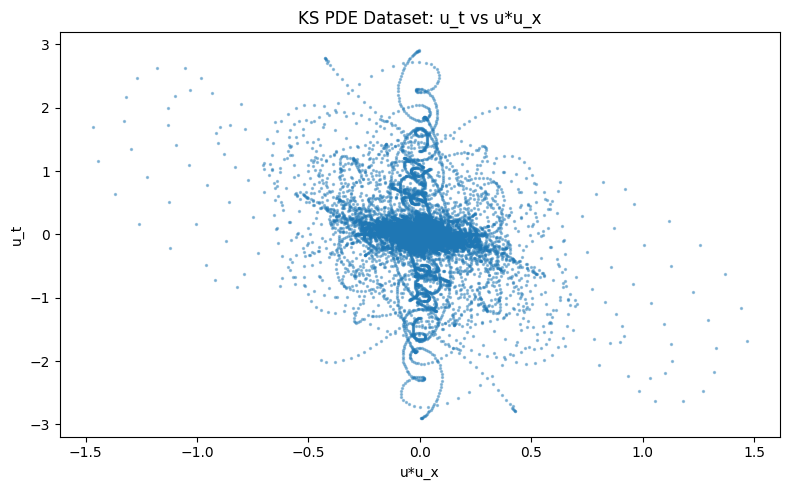

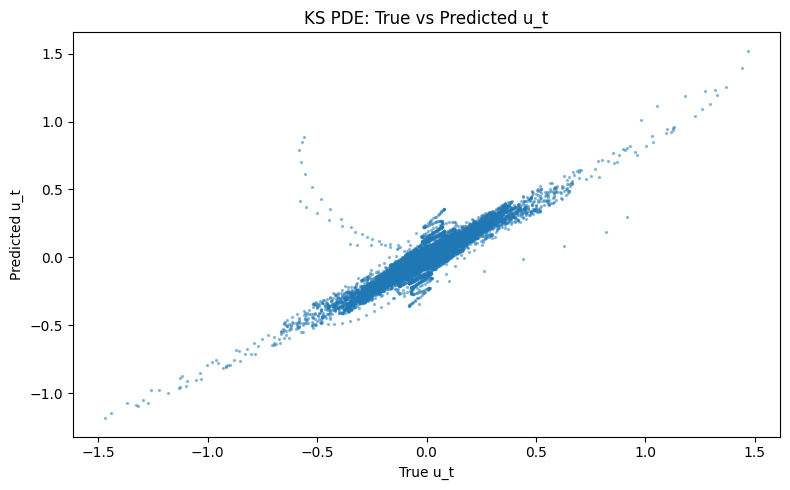

In [ ]:
def create_ks_plot(csv_file, output_name):
    df = pd.read_csv(csv_file)
    plt.figure(figsize=(8, 5))
    plt.scatter(df["y"], df["y_pred"] if "y_pred" in df.columns else df["u_u_x"], s=2, alpha=0.4)
    if "y_pred" in df.columns:
        plt.xlabel("True u_t")
        plt.ylabel("Predicted u_t")
        plt.title("KS PDE: True vs Predicted u_t")
    else:
        plt.xlabel("u*u_x")
        plt.ylabel("u_t")
        plt.title("KS PDE Dataset: u_t vs u*u_x")
    plt.tight_layout()
    plt.savefig(output_name, dpi=300)
    plt.show()

# ------------------------------------------------------------
# Generated KS PDE dataset
# ------------------------------------------------------------
df = generate_ks_dataset(
    nx=256,
    nt=5000,
    time_stride=20,
    space_stride=2
)
# remove flat / weak-dynamics rows
df = df[(np.abs(df["y"]) > 1e-3) & (np.abs(df["u_xx"]) > 1e-4) & (np.abs(df["u_xxxx"]) > 1e-4)].copy()
df.to_csv("datasets/ks_dataset.csv", index=False)
# Explicit feature order for KS
X = df[["u", "u_x", "u_xx", "u_xxxx", "u_u_x"]].values
y = df["y"].values
# Training symbolic regressor
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = train_symbolic_regressor_ks(X_train, y_train, X_test, y_test)
# Converting discovered formula
gen_formula = convert_formula(
    str(model._program),
    var_map={
        "X0": "u",
        "X1": "u_x",
        "X2": "u_xx",
        "X3": "u_xxxx",
        "X4": "u_u_x"
    }
)
# Cleaning formula
u, u_x, u_xx, u_xxxx, u_u_x = sp.symbols("u u_x u_xx u_xxxx u_u_x")
clean_formula = sp.sympify(
    gen_formula,
    locals={
        "u": u,
        "u_x": u_x,
        "u_xx": u_xx,
        "u_xxxx": u_xxxx,
        "u_u_x": u_u_x
    }
)
clean_formula = sp.expand(clean_formula)
clean_formula = sp.simplify(clean_formula)
print("Expected KS PDE:")
print("u_t = -u_u_x - u_xx - u_xxxx")
print("\nRaw discovered formula:")
print(str(model._program))
print("\nConverted formula:")
print("u_t =", gen_formula)
print("\nSimplified discovered KS PDE:")
print("u_t =", clean_formula)
# ------------------------------------------------------------
# Generated derivative predictions
# ------------------------------------------------------------
y_pred = model.predict(X)
gen_df = df.copy()
gen_df["y_pred"] = y_pred
gen_df.to_csv("datasets/ks_dataset_generated.csv", index=False)
create_ks_plot("datasets/ks_dataset.csv", "output/ks_dataset.png")
create_ks_plot("datasets/ks_dataset_generated.csv", "output/ks_dataset_generated.png")

In [ ]:
!rm -rf output